In [24]:
from pathlib import Path
import sys
import os
# Ensure the project root (parent of the notebooks folder) is on sys.path so `src` can be imported
sys.path.insert(0, os.path.abspath(".."))

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from src import config
from src.qc.check_dataset import get_nifti_paths


In [25]:
#Inspect raw file structure

raw_dir = config.RAW_DIR
print(raw_dir)
print((raw_dir / "imagesTr").glob("*.nii.gz"))
print((raw_dir / "labelsTr").glob("*.nii.gz"))

images, labels = get_nifti_paths(raw_dir)
len(images), len(labels)


C:\Users\lynda\Documents\AI Eng\projects\Spleen-Segmentation\data\raw\Task09_Spleen
<generator object Path.glob at 0x000002ABED989250>
<generator object Path.glob at 0x000002ABED989250>


(41, 41)

In [ ]:
#Look at basic shapes, spacings, intensity ranges for a few cases

def summarize_volume(path):
    img = nib.load(str(path))

    # Header info is cheap.
    header = img.header
    shape = header.get_data_shape()
    spacing = header.get_zooms()

    # Sample every 8th slice in z and keep int16 to reduce memory.
    dataobj = img.dataobj
    sample = np.asarray(dataobj[:, :, ::8], dtype=np.int16)

    return {
        "path": path.name,
        "shape": shape,
        "spacing": spacing,
        "min": float(sample.min()),
        "max": float(sample.max()),
    }

summaries = [summarize_volume(p) for p in images[:5]]
summaries



[{'path': 'spleen_10.nii.gz',
  'shape': (512, 512, 55),
  'spacing': (np.float32(0.976562), np.float32(0.976562), np.float32(5.0)),
  'min': -1024.0,
  'max': 1944.0},
 {'path': 'spleen_12.nii.gz',
  'shape': (512, 512, 168),
  'spacing': (np.float32(0.753906), np.float32(0.753906), np.float32(1.5)),
  'min': -1024.0,
  'max': 3072.0},
 {'path': 'spleen_13.nii.gz',
  'shape': (512, 512, 77),
  'spacing': (np.float32(0.742188), np.float32(0.742188), np.float32(2.5)),
  'min': -1024.0,
  'max': 1135.0},
 {'path': 'spleen_14.nii.gz',
  'shape': (512, 512, 54),
  'spacing': (np.float32(0.851562), np.float32(0.851562), np.float32(5.0)),
  'min': -1024.0,
  'max': 1138.0},
 {'path': 'spleen_16.nii.gz',
  'shape': (512, 512, 61),
  'spacing': (np.float32(0.792969), np.float32(0.792969), np.float32(8.0)),
  'min': -1024.0,
  'max': 1616.0}]

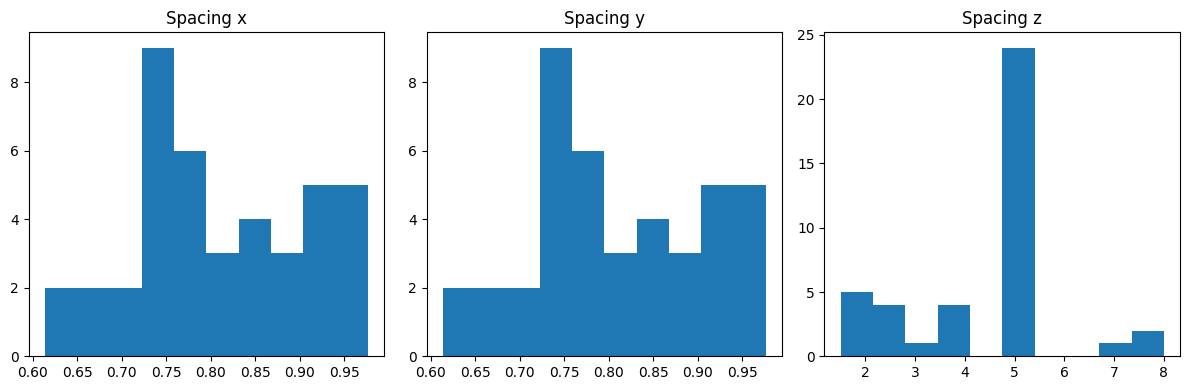

In [ ]:
#Plot histograms of image spacings and intensities

all_spacings = []
all_mins = []
all_maxs = []

for p in images:
    img = nib.load(str(p))

    # Header-only for spacing (very cheap)
    all_spacings.append(img.header.get_zooms())

    # Light subsample in z, keep int16 to avoid MemoryError
    dataobj = img.dataobj
    sample = np.asarray(dataobj[:, :, ::8], dtype=np.int16)
    all_mins.append(sample.min())
    all_maxs.append(sample.max())

all_spacings = np.array(all_spacings)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(all_spacings[:, 0], bins=10)
plt.title("Spacing x")

plt.subplot(1, 3, 2)
plt.hist(all_spacings[:, 1], bins=10)
plt.title("Spacing y")

plt.subplot(1, 3, 3)
plt.hist(all_spacings[:, 2], bins=10)
plt.title("Spacing z")

plt.tight_layout()
plt.show()



spleen_12.nii.gz spleen_12.nii.gz


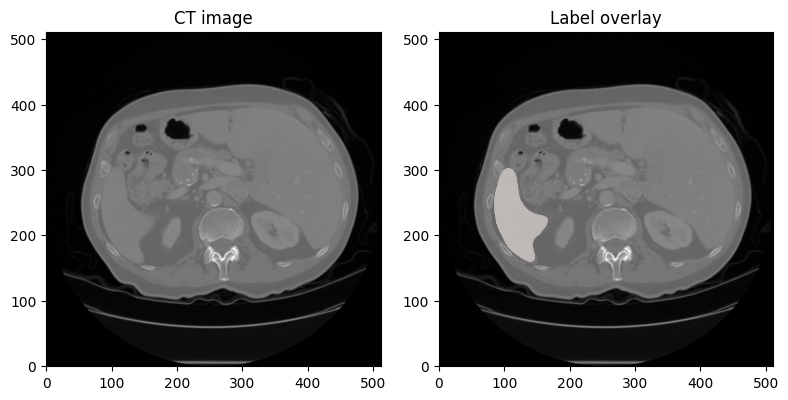

In [ ]:
import random
#Visualize a random case (image + label overlay)

idx = random.randint(0, len(images) - 1)
img_path = images[idx]
lbl_path = labels[idx]
print(img_path.name, lbl_path.name)

img_obj = nib.load(str(img_path)).dataobj   # lazy proxy
lbl_obj = nib.load(str(lbl_path)).dataobj

# Get mid-slice index from header shape, no full load
shape = img_obj.shape
slice_idx = shape[2] // 2

# Read only one slice into memory
img_slice = np.asarray(img_obj[:, :, slice_idx], dtype=np.float32)
lbl_slice = np.asarray(lbl_obj[:, :, slice_idx], dtype=np.int16)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("CT image")
plt.imshow(img_slice.T, cmap="gray", origin="lower")

plt.subplot(1, 2, 2)
plt.title("Label overlay")
plt.imshow(img_slice.T, cmap="gray", origin="lower")
plt.imshow(
    np.ma.masked_where(lbl_slice.T == 0, lbl_slice.T),
    cmap="Reds",
    alpha=0.5,
    origin="lower",
)

plt.tight_layout()
plt.show()



In [34]:
from src.qc.check_dataset import check_dataset
from src import config
import json

check_dataset()

dq_json = config.REPORTS_DIR / "data_quality" / "dataset_stats.json"
dq_stats = json.loads(dq_json.read_text())
list(dq_stats.keys()), len(dq_stats["images"]), len(dq_stats["labels"])


TypeError: Object of type float32 is not JSON serializable

In [35]:
import nibabel as nib
import numpy as np
from src.qc.check_dataset import get_nifti_paths
from src import config

images, labels = get_nifti_paths(config.RAW_DIR)

def quick_min_max(path):
    img = nib.load(str(path))
    dataobj = img.dataobj
    # slice in z to limit memory
    sample = np.asarray(dataobj[:, :, ::8], dtype=np.int16)
    return sample.min(), sample.max()

for p in images[:5]:
    mn, mx = quick_min_max(p)
    print(p.name, mn, mx)


spleen_10.nii.gz -1024 1944
spleen_12.nii.gz -1024 3072
spleen_13.nii.gz -1024 1135
spleen_14.nii.gz -1024 1138
spleen_16.nii.gz -1024 1616
